In [1]:
#import neccessary libraries
import numpy as np
import evaluation as ev
import csv
import pandas as pd
import scipy.stats

In [2]:
#set root file name
root_file = 'Gamma-E300-n1000-part6'

In [3]:
#read noise distribution of desired particle to do energy resolution on for a given energy level
df = pd.read_csv('cluster-noise-distribution_'+root_file+'.csv')

In [4]:
#set run parameters
n_events = 1000
noise = df['noise'][df['n_clusters_mean'].idxmin()]
cluster_n = 1

#modifiedtest_single_photon function (taken from test_stats.py) that returns cluster per hit & energy per hit
#this function calls our model and tests it using the root file defined in datasets.py in the single_photon_dataset function
def clusters_info_t(n_events, noise):
    tbeta = .2
    td = .5
    nmax = n_events
    yielder = ev.TestYielderSinglePhoton()
    yielder.model.signal_threshold = noise
    event_n_t = []
    event_cluster_t = []
    cluster_energy_t = []
    cluster_nhits_t = []
    for i, (event, prediction, clustering) in enumerate(yielder.iter_clustering(tbeta, td, nmax=nmax)):
        #see https://stackoverflow.com/questions/67108215/how-to-get-sum-of-values-in-a-numpy-array-based-on-another-array-with-repetitive
        np.set_printoptions(suppress=True) #suppress scientific notation

        #get true cluster energy
        _, idy, _ = np.unique(event.y, return_counts=True, return_inverse=True)
        energy_values_t = np.round(np.bincount(idy, event.energy),3)

        #get true clusters and get their total energy & hits
        event_cluster_unique_t, n_hits_t = np.unique(event.y, return_counts=True, return_index=False)
        event_i_t = np.full(len(event_cluster_unique_t), i, dtype=int)
        event_n_t = np.append(event_n_t, event_i_t)
        event_cluster_t = np.append(event_cluster_t, event_cluster_unique_t)
        cluster_nhits_t = np.append(cluster_nhits_t, n_hits_t)
        cluster_energy_t = np.append(cluster_energy_t, energy_values_t)
    return event_n_t, event_cluster_t, cluster_nhits_t, cluster_energy_t

#get truth clusters info
ci_t = clusters_info_t(n_events, noise)

#create pandas dataframe with results from cluster info
df_ci_t = pd.DataFrame({'event_n': ci_t[0].astype(np.int64), 'cluster_count': ci_t[1].astype(np.int64), 'n_hits_t': ci_t[2].astype(np.int64), 'energy_value_t': ci_t[3]})
df_ci_t

#write cluster info dataframe to .csv 
df_ci_t.to_csv('cluster-info-truth_'+root_file+'_noise-'+str(noise)+'.csv', index=False)

In [5]:
#read noise distribution of desired particle to do energy resolution on for a given energy level
df_ci_t = pd.read_csv('cluster-info-truth_'+root_file+'_noise-'+str(noise)+'.csv')

In [6]:
#calculate percentage of energy by cluster, per event
df_ci_t['energy_percentage_t'] = df_ci_t['energy_value_t'] / df_ci_t.groupby('event_n')['energy_value_t'].transform('sum')
df_ci_t

,event_n,cluster_count,n_hits_t,energy_value_t,energy_percentage_t
0,0,0,17791,142.533,0.319666
1,0,1,1370,303.348,0.680334
2,1,0,17830,143.927,0.328716
3,1,1,1363,293.919,0.671284
4,2,0,17848,143.441,0.353326
...,...,...,...,...,...
1995,997,1,1359,293.573,0.672136
1996,998,0,18037,144.567,0.332505
1997,998,1,1353,290.214,0.667495
1998,999,0,17835,143.615,0.327952


In [7]:
#get reco cluster info dataframe
df_ci = pd.read_csv('cluster-info_'+root_file+'_noise-'+str(noise)+'.csv')
df_ci

,event_n,clusterindex,n_hits,energy_value,energy_percentage,cluster_count
0,0,0,17797,142.606,0.319829,0
1,0,274,1359,303.029,0.679617,1
2,0,1240,5,0.247,0.000554,2
3,1,0,17841,144.022,0.328933,0
4,1,313,1345,293.720,0.670829,1
...,...,...,...,...,...,...
3963,998,245,2,0.040,0.000092,2
3964,999,0,17865,144.225,0.329344,0
3965,999,584,1305,282.502,0.645105,1
3966,999,122,4,11.032,0.025192,2


In [8]:
#merge dataframes based on cluster_count and keep only main signal cluster
df_r = pd.merge(df_ci_t, df_ci, on=['event_n','cluster_count'], how='outer')
df_r = df_r[df_r['cluster_count']==cluster_n]

df_r = df_r.reset_index(drop=True)

#drop nan values but keep index
df_r = df_r.dropna(subset=['energy_value'])

In [9]:
#calculate cluster response as E_reco/E_gen
df_r['cluster_response'] = np.round(df_r['energy_value']/df_r['energy_value_t'],6)
df_r

,event_n,cluster_count,n_hits_t,energy_value_t,energy_percentage_t,clusterindex,n_hits,energy_value,energy_percentage,cluster_response
0,0,1,1370.0,303.348,0.680334,274,1359,303.029,0.679617,0.998948
1,1,1,1363.0,293.919,0.671284,313,1345,293.720,0.670829,0.999323
2,2,1,1296.0,262.533,0.646674,95,1276,262.300,0.646100,0.999112
3,3,1,1307.0,292.954,0.672101,152,1300,292.813,0.671779,0.999519
4,4,1,1394.0,291.235,0.671957,47,1381,291.125,0.671702,0.999622
...,...,...,...,...,...,...,...,...,...,...
995,995,1,1715.0,287.760,0.667539,29,1592,286.492,0.664597,0.995594
996,996,1,1588.0,290.652,0.665943,409,1464,289.359,0.662980,0.995551
997,997,1,1359.0,293.573,0.672136,195,1352,293.461,0.671881,0.999618
998,998,1,1353.0,290.214,0.667495,340,1302,289.745,0.666416,0.998384


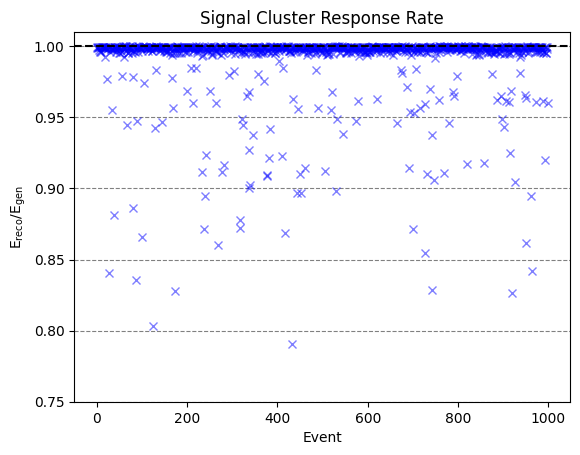

In [10]:
#set y-axis limits so that response is symmetric
ymin = 0.75
ymax = 1.01

ax = df_r.plot(x='event_n', 
               y='cluster_response',
               title = 'Signal Cluster Response Rate',
               ylabel = '$\mathregular{E_{reco}/E_{gen}}$', 
               xlabel =  'Event',
               style='x',
               color='blue',
               legend = None,
               alpha=0.5)

ax.axhline(1.0, color='k', linestyle='--', label='_nolabel_')

ax.set_ylim([ymin, ymax]) #uncomment for centered response

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.get_figure().savefig('cluster_response_rate-'+root_file+'_noise-'+str(noise)+'_signal' + str(cluster_n) +'.png', bbox_inches = 'tight')

In [11]:
#create dataframe for each cluster along their nhits & response rate, per event
n_events=1000
cluster_nhits = np.zeros(shape=(n_events),dtype=int)
cluster_rrate = np.zeros(shape=(n_events))

cluster_nhits = df_r['n_hits']
cluster_rrate = df_r['cluster_response']

df_r_n = pd.DataFrame({'n_hits': cluster_nhits, 'cluster_rate': cluster_rrate})
df_r_n.index.name = 'event_n'
df_r_n = df_r_n.reset_index()
df_r_n

,event_n,n_hits,cluster_rate
0,0,1359,0.998948
1,1,1345,0.999323
2,2,1276,0.999112
3,3,1300,0.999519
4,4,1381,0.999622
...,...,...,...
995,995,1592,0.995594
996,996,1464,0.995551
997,997,1352,0.999618
998,998,1302,0.998384


In [12]:
#set up histogram bining
bin_n = 10
bin_width = (df_r_n['cluster_rate'].max() - df_r_n['cluster_rate'].min())/bin_n
custom_bins = np.arange(df_r_n['cluster_rate'].min()-0.05, df_r_n['cluster_rate'].max()+0.05, bin_width)
custom_bins

array([0.74045  , 0.7614131, 0.7823762, 0.8033393, 0.8243024, 0.8452655,
       0.8662286, 0.8871917, 0.9081548, 0.9291179, 0.950081 , 0.9710441,
       0.9920072, 1.0129703, 1.0339334])

In [13]:
#set up bins weights so that summing the bars up gives 1
bin_weights = np.ones_like(df_r_n['cluster_rate']) / len(df_r_n['cluster_rate'])

In [14]:
#fit data to gaussian distribution
mu, std = scipy.stats.norm.fit(df_r_n['cluster_rate'])
g = scipy.stats.norm.pdf(custom_bins, mu, std)

In [15]:
#get fit weight correction for weighted/density histogram
sums_w, bins_w = np.histogram(df_r_n['cluster_rate'], custom_bins, weights = bin_weights)
sums_d, bins_d = np.histogram(df_r_n['cluster_rate'], custom_bins, density = True)
g_weight = np.amax(sums_w)/np.amax(sums_d)

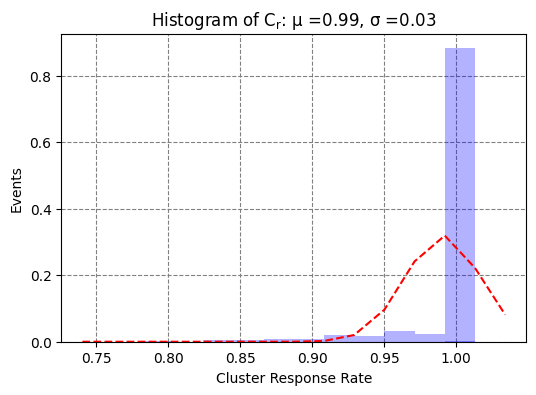

In [16]:
#set x-axis limits so that histogram is centered
xmin = 0
xmax = np.ceil(mu)*2

#plot histogram 
ax = df_r_n.plot('n_hits', 
        kind='hist', 
        bins=custom_bins,
        density=False,
        weights = bin_weights,
        title = 'Histogram of $\mathregular{C_{r}}$: μ ='+str(np.round(mu,2))+', σ ='+str(np.round(std,2)),
        ylabel = 'Events', 
        xlabel='Cluster Response Rate',
        rot = 0,
        color='blue',
        legend = None,
        figsize=(6, 4),
        alpha=0.3)

#plot gaussian fit
ax.plot(custom_bins, g*g_weight, color='red', linestyle='dashed')

#set plot parameters
ax.set_axisbelow(True)
#ax.set_xlim([xmin, xmax]) #uncomment for centered histogram
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.xaxis.grid(color='gray', linestyle='dashed')
ax.get_figure().savefig('cluster_response_rate_histogram-'+root_file+'_noise-'+str(noise)+'_signal' + str(cluster_n) +'.png', bbox_inches = 'tight')